|Machine Learning Lab Assignment 02 |                   |          
|:-----------------------------------:|:-----------------:|
| **Bird Genetic Diversity**           |                    |

|                 |                   | 
|-----------------|:-----------------:|
| **Name**        | Shubham Choudhary |        
| **Roll Number** | 212405015         |

# Bird Genetic Diversity
## Evolutionary theory suggests that species spread over a wider geographic range should have greater genetic diversity. Does this hold true in birds? An observational study of 387 bird species. 

# Data

#### This data includes 387 bird species, along with two measures of their genetic diversity, a measure of the size of their breeding range, their body mass, and whether they are migratory or resident birds. The breeding ranges vary in size from a just few islands in the Seychelles, for the Seychelles warbler (Acrocephalus sechellensis), to enormous ranges of the Southern Ocean for the grey-headed albatross (Thalassarche chrysostoma).

In [58]:
import pandas as pd
import numpy as np

In [59]:
df = pd.read_csv('bird-diversity.csv')
df

,Species,Family,Heterozygosity,Allelic richness,Breeding range size,Body mass,Latitude,Migratory status,References
0,Apteryx australis,Struthioniformes,0.596,4.00,2.0088,2321,45.62,Resident,Shepherd and Lambert 2006; Willoughby et al. 2015
1,Tinamus major,Tinamiformes,0.763,8.56,782.5703,1026,1.54,Resident,Hughes 2010; Willoughby et al. 2015
2,Eudyptes chrysolophus,Sphenisciformes,0.776,10.73,14.5674,4485,54.10,Migratory,Hughes 2010; Willoughby et al. 2015
3,Eudyptula minor,Sphenisciformes,0.540,6.38,60.9832,1108,39.27,Resident,Billing et al. 2007; Willoughby et al. 2015
4,Megadyptes antipodes,Sphenisciformes,0.447,3.25,16.6531,5326,47.30,Resident,Boessenkool et al. 2008; Willoughby et al. 2015
...,...,...,...,...,...,...,...,...,...
382,Zonotrichia leucophrys,Passeriformes,0.850,11.16,2885.6667,28,46.52,Migratory,Poesel et al. 2009; Willoughby et al. 2015
383,Zosterops borbonicus,Passeriformes,0.759,7.75,0.5050,8,20.77,Resident,Bertrand et al. 2012; Willoughby et al. 2015
384,Zosterops flavifrons,Passeriformes,0.152,4.20,1.3202,11,16.21,Resident,Hughes 2010; Phillimore et al. 2008
385,Zosterops lateralis,Passeriformes,0.731,6.83,380.0179,13,22.12,Migratory,Evans and Sheldon 2008; Willoughby et al. 2015


# Goal 1

#### Body size and latitude are thought to be related to genetic diversity for reasons unrelated to breeding range size. Regress heterozygosity against breeding range size, body mass, and latitude. Examine the shape of the relationship, which is thought not to be linear and suspected to have an asymptote. Does the relationship depend on whether the species are migratory? Compare this to the shape you find using allelic richness instead of heterozygosity as the outcome.

# Goal 1.1 : Regress heterozygosity against breeding range size, body mass, and latitude.

### Independent and Dependent Dataset
#### To regress heterozygosity against breeding range size, body mass, and latitude, we take breeding range size, body mass, and latitude as Independent Dataset (X), heterozygosity as Dependent dataset (y).

#### Independent Dataset (X)

In [60]:
X = df[["Breeding range size", "Body mass", "Latitude"]]
X

,Breeding range size,Body mass,Latitude
0,2.0088,2321,45.62
1,782.5703,1026,1.54
2,14.5674,4485,54.10
3,60.9832,1108,39.27
4,16.6531,5326,47.30
...,...,...,...
382,2885.6667,28,46.52
383,0.5050,8,20.77
384,1.3202,11,16.21
385,380.0179,13,22.12


#### Dependent Dataset (y)

In [64]:
y = df["Heterozygosity"]
y

0      0.596
1      0.763
2      0.776
3      0.540
4      0.447
       ...  
382    0.850
383    0.759
384    0.152
385    0.731
386    0.711
Name: Heterozygosity, Length: 387, dtype: float64

## Splitting the dataset into training data and testing data
### It is important to keep some data aside beforehand for testing the predictions of model we are going to train to ensure that the model performs with minimum possible errors which can be confirmed by comparing outcomes of the model by their actual output which was initially kept aside for testing purpose. 

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42)

## Training Data

In [68]:
X_train

,Breeding range size,Body mass,Latitude
258,69.7210,19,3.79
338,13.1212,35,27.01
141,1073.2881,550,76.11
239,267.9417,364,30.38
234,42.5033,19,8.42
...,...,...,...
71,1676.9431,311,28.23
106,4817.1348,1069,56.88
270,0.7701,24,0.55
348,22.2013,32,14.62


In [69]:
y_train

258    0.668
338    0.907
141    0.709
239    0.707
234    0.663
       ...  
71     0.544
106    0.759
270    0.710
348    0.834
102    0.802
Name: Heterozygosity, Length: 270, dtype: float64

## Testing Data

In [70]:
X_test

,Breeding range size,Body mass,Latitude
314,7371.1348,16,45.27
152,692.0493,626,3.63
90,217.7153,528,47.77
266,0.0568,30,28.21
208,3792.5312,30,14.32
...,...,...,...
150,23.0474,312,13.75
109,613.1106,870,42.19
17,3752.8479,3898,40.09
318,9308.5711,21,30.58


In [71]:
y_test

314    0.735
152    0.755
90     0.685
266    0.791
208    0.578
       ...  
150    0.693
109    0.731
17     0.590
318    0.649
24     0.621
Name: Heterozygosity, Length: 117, dtype: float64

## Standardizing the dataset
### Standardization of a dataset is a common requirement for many machine learning estimators: they might behave badly if the individual features do not more or less look like standard normally distributed data (e.g. Gaussian with 0 mean and unit variance).

In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train

array([[-5.24859224e-01, -4.67251634e-01, -1.51012285e+00],
       [-5.41637530e-01, -4.56557111e-01, -6.61592108e-02],
       [-2.27364254e-01, -1.12327150e-01,  2.98718338e+00],
       [-4.66099166e-01, -2.36650981e-01,  1.43408295e-01],
       [-5.32927572e-01, -4.67251634e-01, -1.22220073e+00],
       [-5.25725177e-01, -4.71262080e-01, -5.41883667e-01],
       [ 2.53157878e+00, -4.05758127e-01, -5.74531424e-02],
       [-4.88612560e-01, -4.73935711e-01,  2.54721599e-01],
       [ 3.09892813e-01, -4.61235965e-01,  1.14709362e+00],
       [ 4.30711182e-01, -2.87449965e-01,  5.21500411e-01],
       [-5.45212270e-01, -4.70593673e-01, -5.26958978e-01],
       [-4.63478006e-01, -2.57371619e-01, -1.73896808e+00],
       [-5.45100098e-01, -3.87711119e-01, -3.51593884e-01],
       [-9.12703690e-02, -4.73267304e-01,  2.31712703e-01],
       [-5.15802108e-01, -4.77277750e-01,  3.62925593e-01],
       [-5.20947997e-01, -4.68588450e-01, -8.90748268e-01],
       [ 1.67293428e-01, -4.41852142e-01

In [74]:
X_test = scaler.transform(X_test)
X_test

array([[ 1.63955398e+00, -4.69256857e-01,  1.06936086e+00],
       [-3.40377749e-01, -6.15281658e-02, -1.52007265e+00],
       [-4.80988157e-01, -1.27032120e-01,  1.22482637e+00],
       [-5.45510308e-01, -4.59899150e-01,  8.46423324e-03],
       [ 5.78721501e-01, -4.59899150e-01, -8.55302132e-01],
       [-5.45521988e-01, -4.37841696e-01, -1.66621022e+00],
       [ 2.42549683e+00, -3.57632773e-01,  2.51612288e-01],
       [-1.12740036e-01,  3.88310210e-01, -1.58785561e+00],
       [-5.45016355e-01, -4.59230742e-01, -2.63289476e-01],
       [-2.55113210e-01,  3.52782114e+00, -1.10404695e+00],
       [ 4.41329457e-01, -3.53622327e-01,  1.06718435e-01],
       [ 1.95193152e-01,  9.11673433e-01, -3.34181747e-01],
       [ 1.57614535e-01, -4.59899150e-01, -2.83189061e-01],
       [-4.82813589e-01,  1.28598174e+00,  2.18187204e+00],
       [-5.05326183e-01, -4.23805134e-01,  6.53957024e-01],
       [-5.33638755e-01, -4.68588450e-01, -1.56049368e+00],
       [ 1.85210622e+00, -3.34238504e-01

## Linear Regression Model

In [75]:
from sklearn.linear_model import LinearRegression

In [76]:
regression = LinearRegression()
regression.fit(X_train, y_train)

LinearRegression()

## Cross Validation 
### Cross Validation involves splitting the data into subsets, training the model on one subset, and testing it on the remaining subset. This process is repeated multiple times, ensuring that the model is evaluated on different data to assess its performance.

In [77]:
from sklearn.model_selection import cross_val_score

In [78]:
mse = cross_val_score(regression, X_train, y_train, scoring = 'neg_mean_squared_error', cv=10)
mse

array([-0.01515441, -0.0202209 , -0.01506544, -0.01307184, -0.025274  ,
       -0.02857155, -0.0307656 , -0.01730846, -0.03249605, -0.01858617])

## Mean Squared Error

In [79]:
np.mean(mse)

np.float64(-0.021651442534747965)

## Model's Performance on the test data

In [80]:
reg_pred = regression.predict(X_test)
reg_pred

array([0.67534469, 0.65582669, 0.65348311, 0.66779365, 0.67368792,
       0.6695583 , 0.67554601, 0.63971815, 0.6681929 , 0.51879783,
       0.66758704, 0.6190784 , 0.67109344, 0.59816199, 0.66557736,
       0.67061318, 0.67150007, 0.64648601, 0.67002581, 0.6671849 ,
       0.65144835, 0.66883453, 0.67097927, 0.51292862, 0.67155483,
       0.6553973 , 0.66945305, 0.66241544, 0.66726356, 0.60778023,
       0.66917675, 0.67212357, 0.6599257 , 0.65941837, 0.65844301,
       0.66887022, 0.64593711, 0.66666542, 0.67655763, 0.66977486,
       0.64349519, 0.65866554, 0.6692715 , 0.66976939, 0.56204974,
       0.66927931, 0.67129318, 0.65400525, 0.60999805, 0.65413452,
       0.66895982, 0.65355653, 0.66393628, 0.66850016, 0.65382646,
       0.66776349, 0.66622994, 0.66738651, 0.67418176, 0.66735809,
       0.66805387, 0.669074  , 0.65864522, 0.67227347, 0.54191604,
       0.65199969, 0.63913   , 0.66832819, 0.61891749, 0.66830967,
       0.67288678, 0.63086576, 0.63934972, 0.60200166, 0.63960

## Plotting the results

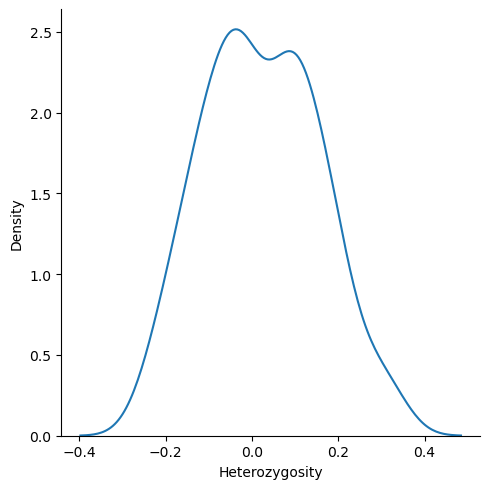

In [81]:
import seaborn as sns
sns.displot(reg_pred-y_test, kind='kde')

## R-squared value

In [82]:
from sklearn.metrics import r2_score
score = r2_score(y_test, reg_pred)
score

0.08302693845080167

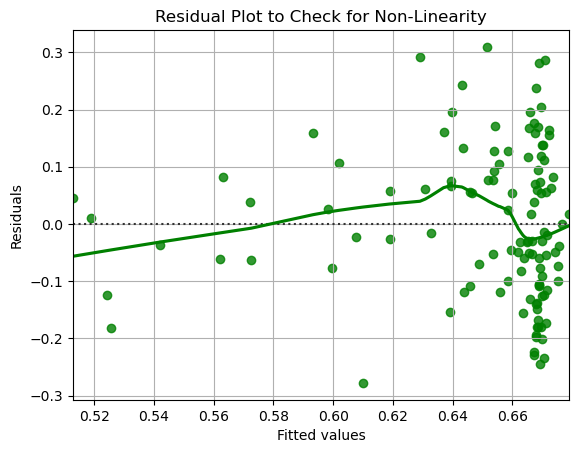

In [83]:
import matplotlib.pyplot as plt
sns.residplot(x=reg_pred, y=reg_pred-y_test, lowess=True, color="g")
plt.title('Residual Plot to Check for Non-Linearity')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Result

### 1. Linearity

#### This residual plot clearly indicates a non-linear relationship. For the relationship to be linear, the solid green line, which represents the smoothed average of the residuals must be flat. This curved shape in the residuals plot is strong evidence that a simple linear model is not an appropriate fit for our data.

### 2. Distribution of errors

#### Errors are in the range from -0.2 to 0.2 but errors are not distributed uniformly around 0.

### 3. R squared value

#### Here, we have low R-squared value in regression analysis which indicates that the model does not effectively explain the variability in the dependent variable. This means that the independent variables in the model do not contribute significantly to predicting the response variable. A low R-squared value suggests that the model's fit is poor, and the variance in the dependent variable remains unexplained. This can be due to several reasons, including a weak relationship between the variables, missing important variables, or a non-linear relationship that the model cannot capture.

# Goal 1.2 Examine the shape of the relationship, which is thought not to be linear and suspected to have an asymptote.

# Result

#### The relationship is not linear; it is expected to have a curved shape that levels off.

#### The term asymptote means that the relationship approaches a certain limit. In this context, it suggests that as an independent variable like breeding range size increases, genetic diversity will also increase, but at a progressively slower rate. Eventually, the curve will flatten out and approach a maximum value, indicating that further increases in breeding range size will have little to no additional effect on genetic diversity. This concept is often referred to as diminishing returns.

# Goal 1.3 Does the relationship depend on whether the species are migratory? 

#### An interaction term is a variable in a statistical model, like a regression, that represents the combined effect of two or more independent variables on the dependent variable. It's used when the effect of one independent variable on the outcome is dependent on the value of another independent variable.

In [84]:
import statsmodels.formula.api as smf

df = pd.read_csv('bird-diversity.csv')
df = df.rename(columns={'Migratory status': 'migratory_status'})
df['log_breeding_range_size'] = np.log(df['Breeding range size'])
model = smf.ols(
    'Heterozygosity ~ log_breeding_range_size + C(migratory_status) + log_breeding_range_size:C(migratory_status)',
    data=df
)

results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:         Heterozygosity   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     11.65
Date:                Sat, 16 Aug 2025   Prob (F-statistic):           2.55e-07
Time:                        18:02:06   Log-Likelihood:                 209.32
No. Observations:                 387   AIC:                            -410.6
Df Residuals:                     383   BIC:                            -394.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

#  Result

#### Yes, the relationship depend on whether the species are migratory
#### The p-value for the interaction term, log_breeding_range_size:C(Migratory status)[T.Resident], is 0.001. Since this value is less than the standard significance level of 0.05, the interaction is statistically significant. This means there is a significant difference in the effect of breeding range size on genetic diversity between resident and migratory birds.

# Goal 1.4 Compare this to the shape you find using allelic richness instead of heterozygosity as the outcome.

In [85]:
X

,Breeding range size,Body mass,Latitude
0,2.0088,2321,45.62
1,782.5703,1026,1.54
2,14.5674,4485,54.10
3,60.9832,1108,39.27
4,16.6531,5326,47.30
...,...,...,...
382,2885.6667,28,46.52
383,0.5050,8,20.77
384,1.3202,11,16.21
385,380.0179,13,22.12


In [86]:
z = df["Allelic richness"]
z

0       4.00
1       8.56
2      10.73
3       6.38
4       3.25
       ...  
382    11.16
383     7.75
384     4.20
385     6.83
386     5.08
Name: Allelic richness, Length: 387, dtype: float64

In [87]:
X_train, X_test, z_train, z_test = train_test_split(X, z, test_size = 0.30, random_state = 42)

In [88]:
X_train

,Breeding range size,Body mass,Latitude
258,69.7210,19,3.79
338,13.1212,35,27.01
141,1073.2881,550,76.11
239,267.9417,364,30.38
234,42.5033,19,8.42
...,...,...,...
71,1676.9431,311,28.23
106,4817.1348,1069,56.88
270,0.7701,24,0.55
348,22.2013,32,14.62


In [89]:
z_train

258     8.82
338     9.50
141     7.05
239     8.67
234     8.27
       ...  
71      4.67
106    11.00
270     4.69
348    13.86
102    10.22
Name: Allelic richness, Length: 270, dtype: float64

In [90]:
X_test

,Breeding range size,Body mass,Latitude
314,7371.1348,16,45.27
152,692.0493,626,3.63
90,217.7153,528,47.77
266,0.0568,30,28.21
208,3792.5312,30,14.32
...,...,...,...
150,23.0474,312,13.75
109,613.1106,870,42.19
17,3752.8479,3898,40.09
318,9308.5711,21,30.58


In [91]:
z_test

314     9.56
152    11.44
90      9.36
266     7.89
208    10.57
       ...  
150     6.73
109    10.50
17      4.00
318     8.11
24      7.09
Name: Allelic richness, Length: 117, dtype: float64

In [92]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train

array([[-5.24859224e-01, -4.67251634e-01, -1.51012285e+00],
       [-5.41637530e-01, -4.56557111e-01, -6.61592108e-02],
       [-2.27364254e-01, -1.12327150e-01,  2.98718338e+00],
       [-4.66099166e-01, -2.36650981e-01,  1.43408295e-01],
       [-5.32927572e-01, -4.67251634e-01, -1.22220073e+00],
       [-5.25725177e-01, -4.71262080e-01, -5.41883667e-01],
       [ 2.53157878e+00, -4.05758127e-01, -5.74531424e-02],
       [-4.88612560e-01, -4.73935711e-01,  2.54721599e-01],
       [ 3.09892813e-01, -4.61235965e-01,  1.14709362e+00],
       [ 4.30711182e-01, -2.87449965e-01,  5.21500411e-01],
       [-5.45212270e-01, -4.70593673e-01, -5.26958978e-01],
       [-4.63478006e-01, -2.57371619e-01, -1.73896808e+00],
       [-5.45100098e-01, -3.87711119e-01, -3.51593884e-01],
       [-9.12703690e-02, -4.73267304e-01,  2.31712703e-01],
       [-5.15802108e-01, -4.77277750e-01,  3.62925593e-01],
       [-5.20947997e-01, -4.68588450e-01, -8.90748268e-01],
       [ 1.67293428e-01, -4.41852142e-01

In [93]:
X_test = scaler.transform(X_test)
X_test

array([[ 1.63955398e+00, -4.69256857e-01,  1.06936086e+00],
       [-3.40377749e-01, -6.15281658e-02, -1.52007265e+00],
       [-4.80988157e-01, -1.27032120e-01,  1.22482637e+00],
       [-5.45510308e-01, -4.59899150e-01,  8.46423324e-03],
       [ 5.78721501e-01, -4.59899150e-01, -8.55302132e-01],
       [-5.45521988e-01, -4.37841696e-01, -1.66621022e+00],
       [ 2.42549683e+00, -3.57632773e-01,  2.51612288e-01],
       [-1.12740036e-01,  3.88310210e-01, -1.58785561e+00],
       [-5.45016355e-01, -4.59230742e-01, -2.63289476e-01],
       [-2.55113210e-01,  3.52782114e+00, -1.10404695e+00],
       [ 4.41329457e-01, -3.53622327e-01,  1.06718435e-01],
       [ 1.95193152e-01,  9.11673433e-01, -3.34181747e-01],
       [ 1.57614535e-01, -4.59899150e-01, -2.83189061e-01],
       [-4.82813589e-01,  1.28598174e+00,  2.18187204e+00],
       [-5.05326183e-01, -4.23805134e-01,  6.53957024e-01],
       [-5.33638755e-01, -4.68588450e-01, -1.56049368e+00],
       [ 1.85210622e+00, -3.34238504e-01

In [94]:
regression = LinearRegression()
regression.fit(X_train, z_train)

LinearRegression()

In [95]:
mse = cross_val_score(regression, X_train, z_train, scoring = 'neg_mean_squared_error', cv=10)
mse

array([-13.60561498, -14.9586826 , -28.49823896, -19.74602583,
       -12.11455369, -22.50434377, -30.25058935, -23.02112962,
       -13.85606038, -19.61580805])

In [96]:
np.mean(mse)

np.float64(-19.817104723236188)

In [97]:
reg_pred = regression.predict(X_test)
reg_pred

array([9.25805387, 7.80475645, 8.8667355 , 8.80638065, 8.52443106,
       8.17665051, 8.85615679, 7.27220662, 8.70753282, 3.85488375,
       8.74658583, 7.13477276, 8.71976981, 7.59720777, 8.99920381,
       8.2502682 , 9.00769473, 8.26299484, 8.33027616, 8.91896942,
       8.65835599, 8.71245774, 8.20075797, 4.11379569, 9.48827732,
       8.70621283, 8.79910138, 8.39326208, 9.06843724, 7.44704548,
       8.56672868, 8.59846335, 7.67114315, 9.18593317, 8.57483349,
       9.08275005, 9.01355149, 8.51561183, 8.87294171, 8.46908976,
       7.98004022, 8.61188174, 8.6856509 , 8.34324769, 5.97554894,
       8.6838056 , 8.88833884, 8.55926865, 6.63573199, 7.79644364,
       8.86731823, 7.99997883, 8.72816191, 8.84141924, 8.16280711,
       8.64059673, 9.22661004, 8.9138127 , 8.68872065, 8.75381825,
       8.82863084, 8.65617881, 8.46711336, 9.43089712, 5.90799775,
       8.56711874, 7.94482261, 8.85367893, 7.72321682, 8.83024432,
       8.64374817, 7.68677747, 8.23161497, 6.80338074, 8.22375

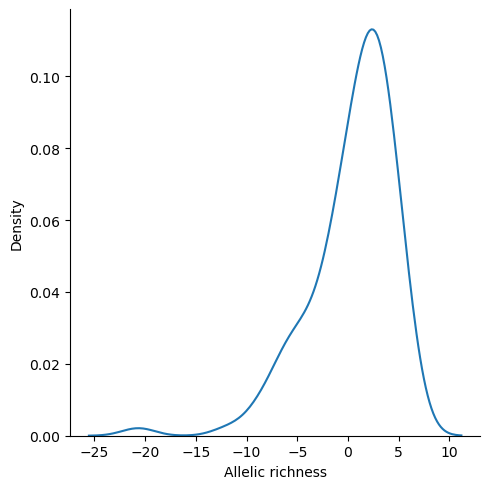

In [98]:
import seaborn as sns
sns.displot(reg_pred-z_test, kind='kde')

In [99]:
from sklearn.metrics import r2_score
score = r2_score(z_test, reg_pred)
score

0.010014279548042126

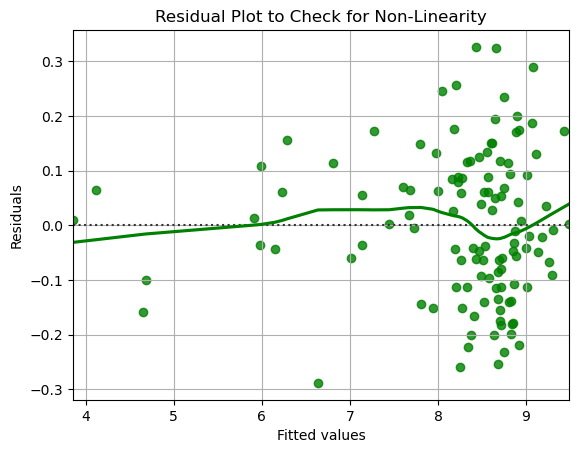

In [100]:
import matplotlib.pyplot as plt
sns.residplot(x=reg_pred, y=reg_pred-y_test, lowess=True, color="g")
plt.title('Residual Plot to Check for Non-Linearity')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Result

### 1. Linearity

#### This residual plot clearly indicates a linear relationship. For the relationship to be linear, the solid green line, which represents the smoothed average of the residuals must be flat. This flat line in the residuals plot is strong evidence that a simple linear model is not an appropriate fit for our data.

### 2. Distribution of errors

#### Errors are distributed uniformly but are right skewed.

### 3. R square value

#### Here, we have low R-squared value in regression analysis which indicates that the model does not effectively explain the variability in the dependent variable. This means that the independent variables in the model do not contribute significantly to predicting the response variable. A low R-squared value suggests that the model's fit is poor, and the variance in the dependent variable remains unexplained. 

# Goal 02

## Species in this dataset are grouped into families; by definitions, species within a family are more similar than species in two different families. This may have effects on the assumptions of the regression. What assumptions may be violated, and what effect would this have on your results? (Note that the original paper accounted for this effect by taking into account the species’ phylogenetic trees.)

# Answer

## Violated Assumption

### Standard regression models assume that the error terms (residuals) for each observation are independent of each other. 
### Because species within the same family are more genetically and biologically similar than species from different families, their residuals are likely to be correlated. For example, if a family of birds is particularly well-adapted to a certain environment, the residuals for all species in that family might trend positively or negatively together, violating the independence assumption. 

## Effect on Results

### P-values 

#### The standard errors of the regression coefficients will be underestimated. This leads to inflated t-statistics and F-statistics, which can, in turn, result in p-values that are smaller than they should be. This increases the risk of making a Type I error, where you incorrectly conclude that a predictor variable is statistically significant when it is not

### Confidence Intervals

#### The confidence intervals for the regression coefficients will be too narrow, giving a false sense of precision in the estimates.

# Goal 03

## Fit a hierarchical model to account for this effect, using family to define the hierarchy. How do your results change?

#### Here, we are using Heterozygosity as the response variable and Allelic richness as the predictor, with Family as the grouping variable.

#### By comparing the results of a standard linear regression to a hierarchical model, we can see how accounting for the non-independence of species within a family affects the statistical inference.

In [101]:
print("                         Standard Linear Regression Model ")
lm = smf.ols('Heterozygosity ~ Q("Allelic richness")', data=df).fit()
print(lm.summary())
print("\n")

print("               Hierarchical Mixed-Effects Model ")
hierarchical_model = smf.mixedlm('Heterozygosity ~ Q("Allelic richness")',
                                 data=df,
                                 groups=df['Family']).fit()
print(hierarchical_model.summary())

                         Standard Linear Regression Model 
                            OLS Regression Results                            
Dep. Variable:         Heterozygosity   R-squared:                       0.439
Model:                            OLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                     301.1
Date:                Sat, 16 Aug 2025   Prob (F-statistic):           3.05e-50
Time:                        18:04:11   Log-Likelihood:                 304.22
No. Observations:                 387   AIC:                            -604.4
Df Residuals:                     385   BIC:                            -596.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

E:\Anaconda\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


# Result

### 1. Regression Coefficients

#### The coefficient for Allelic richness is very similar in both models: 0.0219 in the standard regression and 0.021 in the hierarchical model. This suggests that while the relationship between the variables remains the same, the hierarchical model more accurately reflects the uncertainty of the estimates

### 2. Standard Errors and p-values

#### The standard error for the Allelic richness predictor is 0.001 for both the models. 
#### The P>|z| value for the predictor is 0.000 for both models, indicating that the relationship is highly significant regardless of the model choice. However, in more marginal cases, the hierarchical model's standard errors would be larger, leading to higher p-values and a more conservative test of significance. This is because the hierarchical model correctly accounts for the dependencies in the data, preventing the standard errors from being underestimated.

### 3. Confidence Intervals

#### The 95% confidence interval for the Allelic richness coefficient in the standard regression is [0.019, 0.024], while in the hierarchical model, it is [0.018, 0.023]. While the standard error is similar, the hierarchical model has higher precision because it is more efficient at using the available information by accounting for the nested structure of the data.

# CONCLUSION

## In this project, I learned application of linear regression. The key idea for applying linear regression model in a dataset is that I must keep some data seperately as "test data" and train the model on the "training data". After fitting linear regression model in dataset and cross validation, I can finally test my model with unseen test data and compare the predicted outcomes against actual outcomes. In this way, I can check capabilities of my model to predict outcome for a unseen data.